# Visualize Leakage

  config   roc_auc     auprc  seg_sensitivity  seg_specificity    seg_f1  \
0    A10  0.991869  0.745563         0.981481         0.948955  0.456100   
1    B10  0.993659  0.750689         0.960648         0.979685  0.645136   
2    C10  0.979904  0.538994         0.000000         1.000000  0.000000   
3    D10  0.997283  0.889027         0.850529         0.993120  0.767791   
4    E10  0.997962  0.919370         0.671958         0.998952  0.762064   
5    F10  0.980786  0.558552         0.000000         1.000000  0.000000   
6    G10  0.997387  0.919692         0.674272         0.999308  0.777955   
7    H10  0.994083  0.936224         0.653439         1.000000  0.778372   
8    I10  0.980786  0.558874         0.000000         1.000000  0.000000   

          fp         fn  
0  32.666667   0.333333  
1  14.333333   0.666667  
2   0.000000  13.666667  
3   5.333333   2.000000  
4   1.000000   4.000000  
5   0.000000  13.666667  
6   0.666667   4.000000  
7   0.000000   4.333333  
8   0

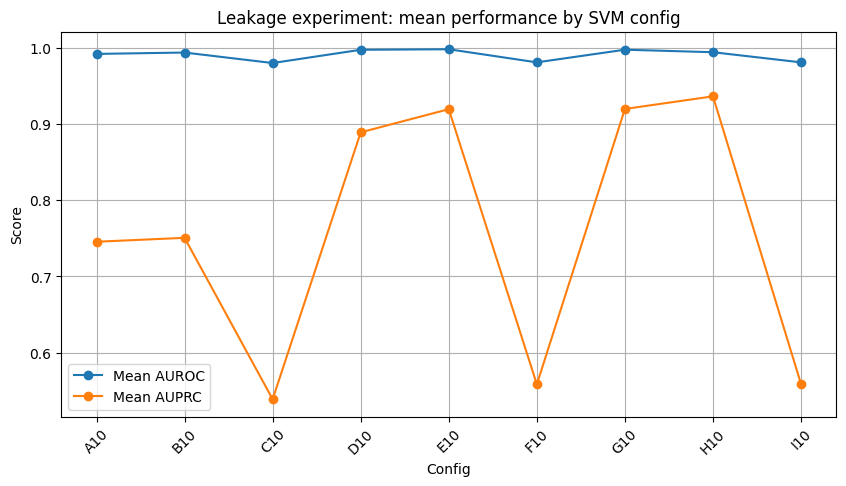

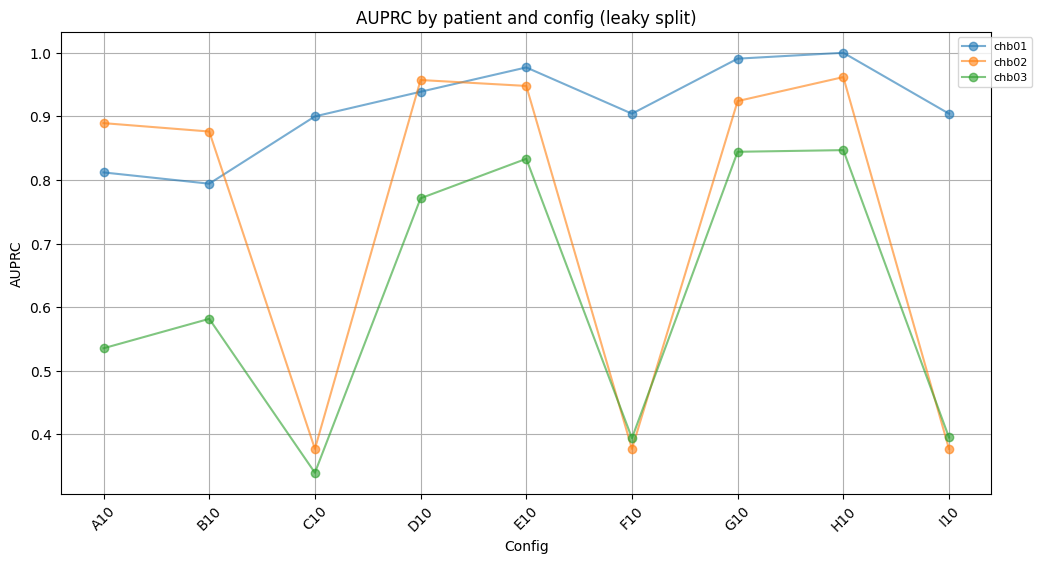

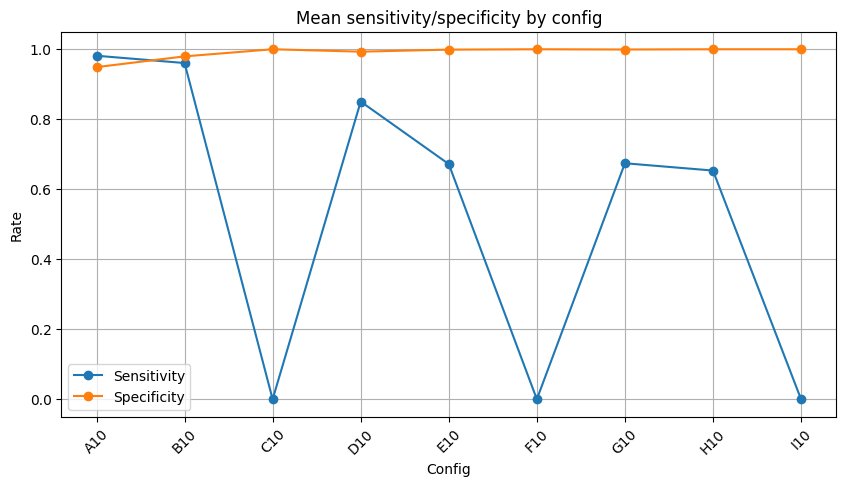

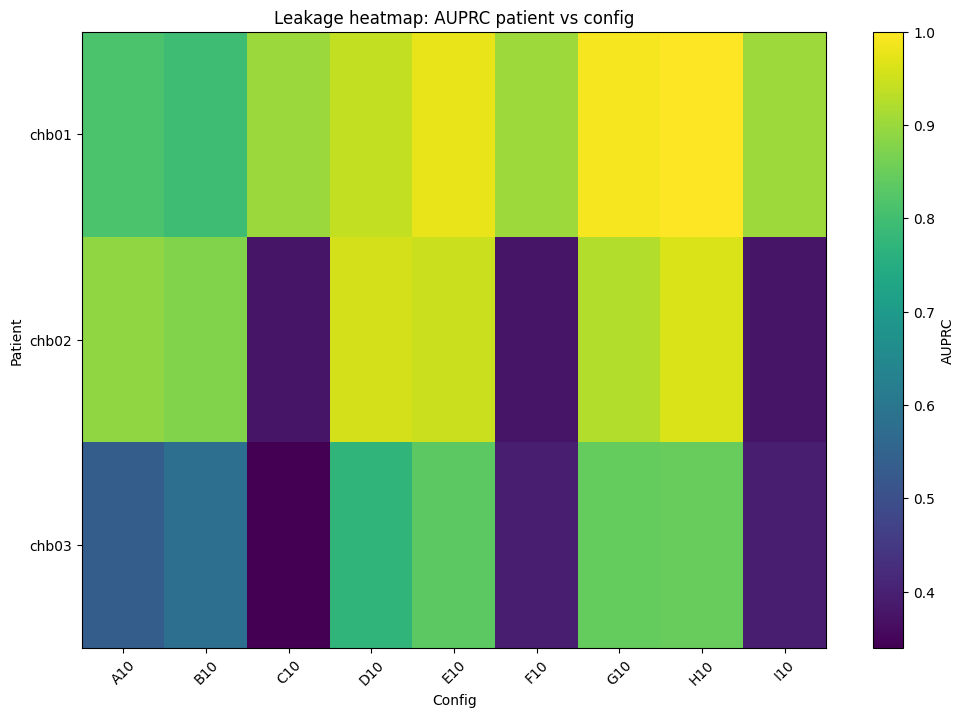

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("LEAKY_RESULTS_seizure_only.csv")


# =====================================================
# 1. Mean performance across ALL patients by config
# =====================================================

config_summary = (
    df.groupby("config")
    [
        [
            "roc_auc",
            "auprc",
            "seg_sensitivity",
            "seg_specificity",
            "seg_f1",
            "fp",
            "fn"
        ]
    ]
    .mean()
    .reset_index()
)


print(config_summary)



# =====================================================
# 2. Compare AUROC and AUPRC by config
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(
    config_summary["config"],
    config_summary["roc_auc"],
    marker="o",
    label="Mean AUROC"
)

plt.plot(
    config_summary["config"],
    config_summary["auprc"],
    marker="o",
    label="Mean AUPRC"
)

plt.xlabel("Config")
plt.ylabel("Score")
plt.title("Leakage experiment: mean performance by SVM config")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()



# =====================================================
# 3. AUPRC for every patient (shows leakage consistency)
# =====================================================

plt.figure(figsize=(12,6))


for patient in df["patient"].unique():

    d = df[df["patient"] == patient]

    plt.plot(
        d["config"],
        d["auprc"],
        marker="o",
        alpha=0.6,
        label=patient
    )


plt.xlabel("Config")
plt.ylabel("AUPRC")
plt.title("AUPRC by patient and config (leaky split)")
plt.xticks(rotation=45)
plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.05,1),
    fontsize=8
)

plt.show()



# =====================================================
# 4. Sensitivity vs Specificity per config
# =====================================================

plt.figure(figsize=(10,5))


plt.plot(
    config_summary["config"],
    config_summary["seg_sensitivity"],
    marker="o",
    label="Sensitivity"
)

plt.plot(
    config_summary["config"],
    config_summary["seg_specificity"],
    marker="o",
    label="Specificity"
)


plt.xlabel("Config")
plt.ylabel("Rate")
plt.title("Mean sensitivity/specificity by config")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()



# =====================================================
# 5. Heatmap: patient x config AUPRC
# =====================================================

import numpy as np


heat = df.pivot(
    index="patient",
    columns="config",
    values="auprc"
)


plt.figure(figsize=(12,8))


plt.imshow(
    heat.values,
    aspect="auto"
)


plt.colorbar(
    label="AUPRC"
)


plt.xticks(
    range(len(heat.columns)),
    heat.columns,
    rotation=45
)

plt.yticks(
    range(len(heat.index)),
    heat.index
)


plt.title("Leakage heatmap: AUPRC patient vs config")

plt.xlabel("Config")
plt.ylabel("Patient")

plt.show()

  config   roc_auc     auprc  seg_accuracy  seg_sensitivity  seg_specificity  \
0    A10  0.991869  0.745563      0.949582         0.981481         0.948955   
1    B10  0.993659  0.750689      0.979383         0.960648         0.979685   
2    C10  0.979904  0.538994      0.981258         0.000000         1.000000   
3    D10  0.997283  0.889027      0.990548         0.850529         0.993120   
4    E10  0.997962  0.919370      0.992903         0.671958         0.998952   
5    F10  0.980786  0.558552      0.981258         0.000000         1.000000   
6    G10  0.997387  0.919692      0.993235         0.674272         0.999308   
7    H10  0.994083  0.936224      0.993584         0.653439         1.000000   
8    I10  0.980786  0.558874      0.981258         0.000000         1.000000   

     seg_f1         fp         fn  
0  0.456100  32.666667   0.333333  
1  0.645136  14.333333   0.666667  
2  0.000000   0.000000  13.666667  
3  0.767791   5.333333   2.000000  
4  0.762064   1.000

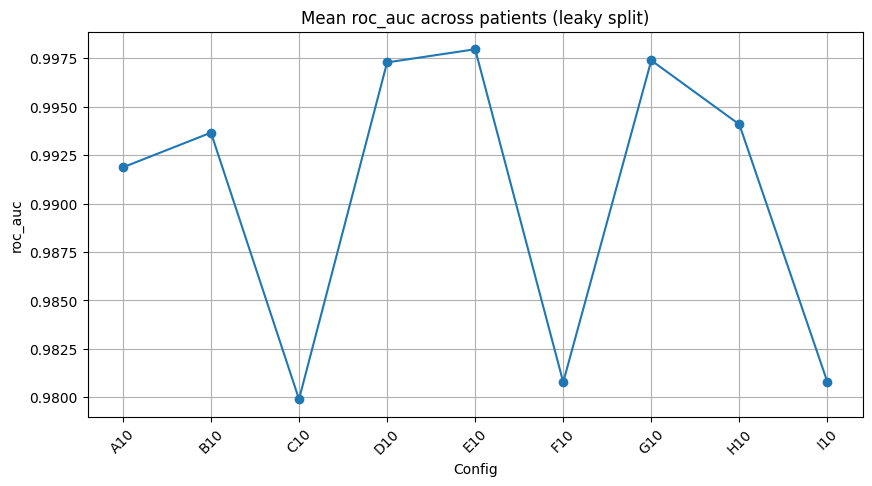

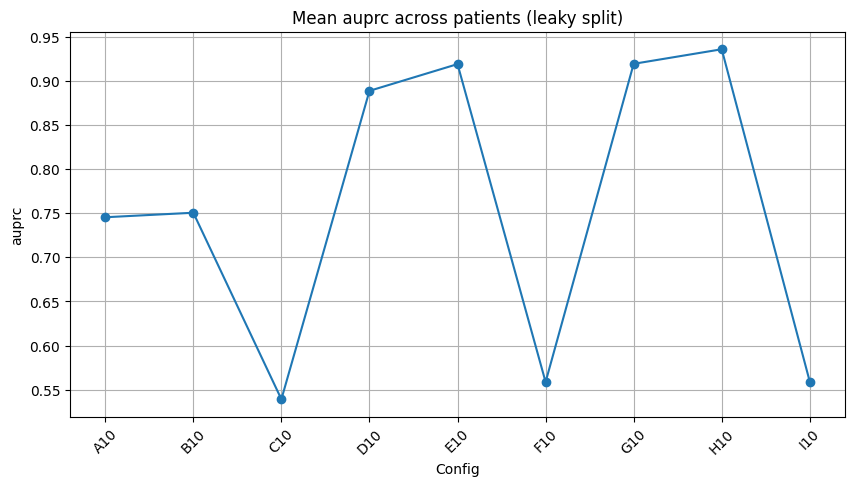

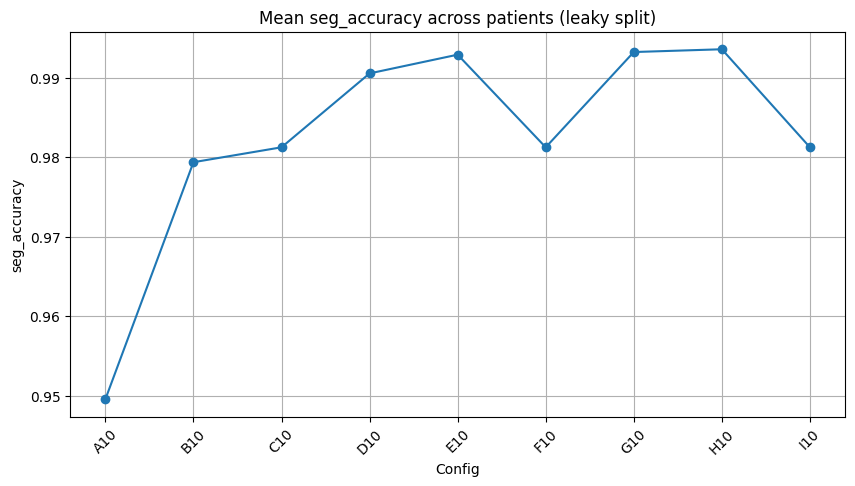

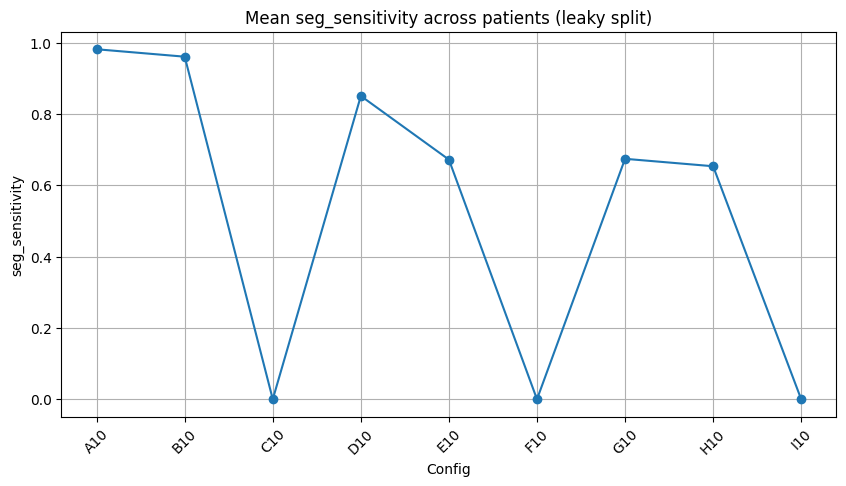

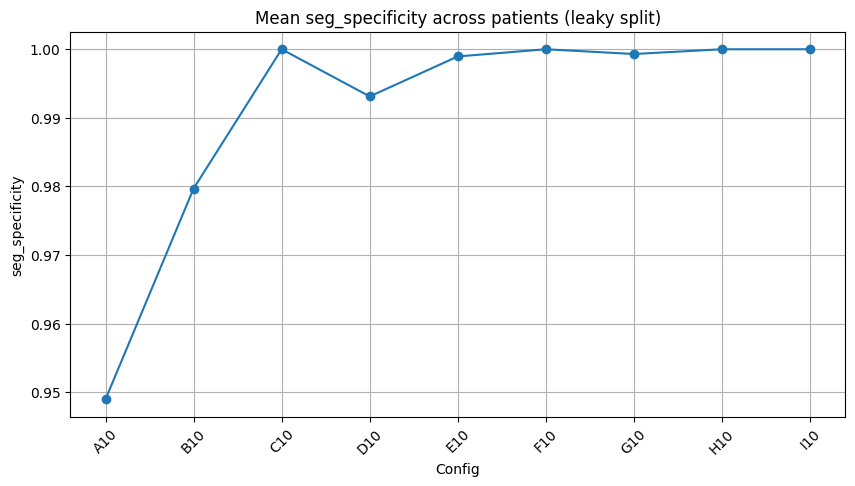

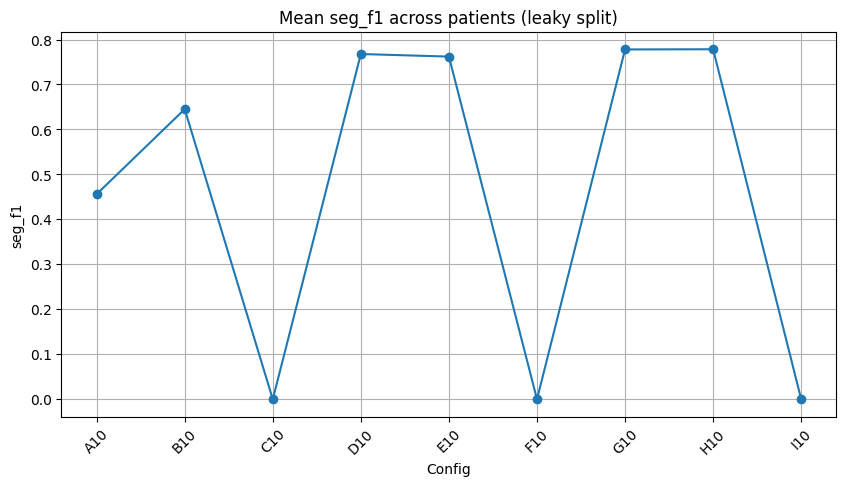

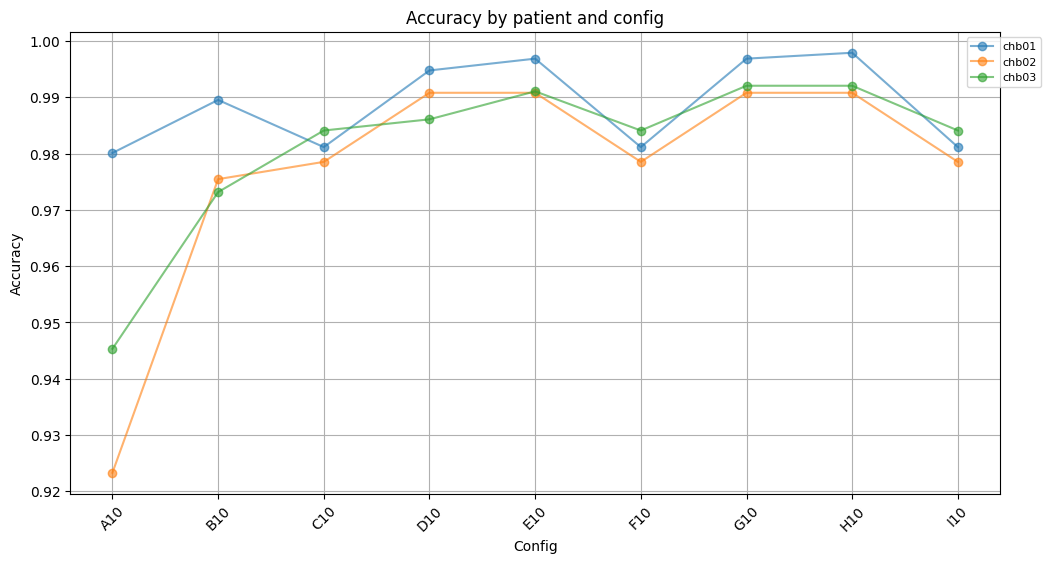

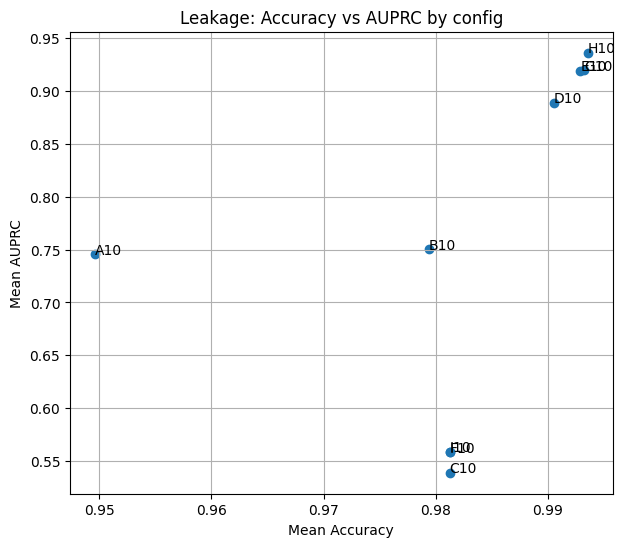

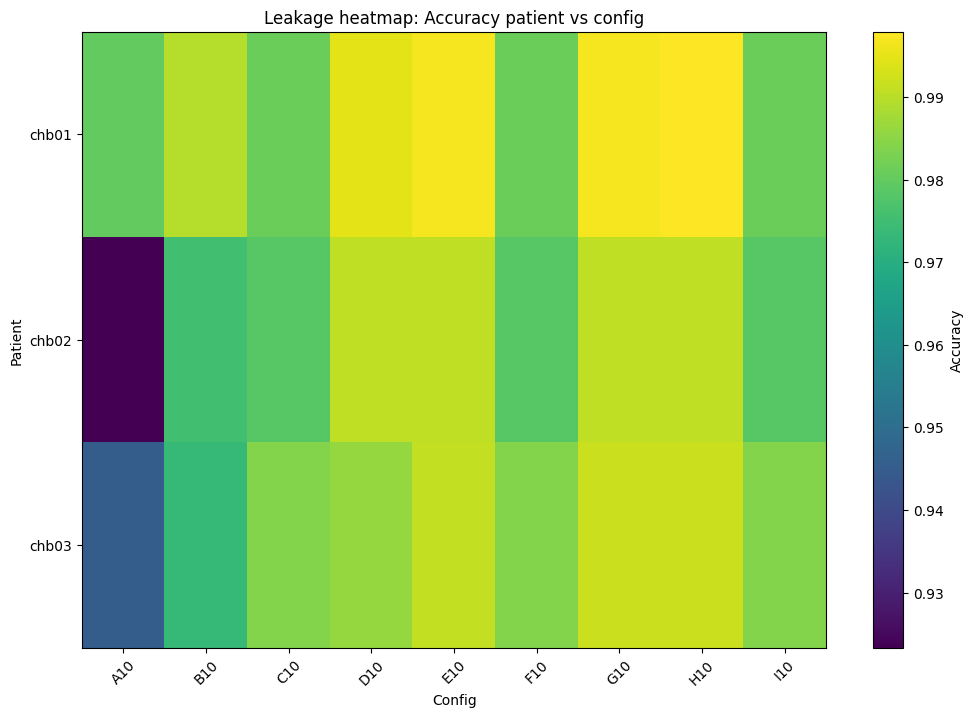

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("LEAKY_RESULTS_seizure_only.csv")


# =====================================================
# 1. Mean metrics across ALL patients by config
# =====================================================

config_summary = (
    df.groupby("config")
    [
        [
            "roc_auc",
            "auprc",
            "seg_accuracy",
            "seg_sensitivity",
            "seg_specificity",
            "seg_f1",
            "fp",
            "fn"
        ]
    ]
    .mean()
    .reset_index()
)


print(config_summary)



# =====================================================
# 2. Compare all main metrics by config
# =====================================================

metrics = [
    "roc_auc",
    "auprc",
    "seg_accuracy",
    "seg_sensitivity",
    "seg_specificity",
    "seg_f1"
]


for metric in metrics:

    plt.figure(figsize=(10,5))

    plt.plot(
        config_summary["config"],
        config_summary[metric],
        marker="o"
    )

    plt.xlabel("Config")
    plt.ylabel(metric)
    plt.title(f"Mean {metric} across patients (leaky split)")
    plt.xticks(rotation=45)
    plt.grid(True)

    plt.show()



# =====================================================
# 3. Per-patient accuracy by config
# =====================================================

plt.figure(figsize=(12,6))


for patient in df["patient"].unique():

    d = df[df["patient"] == patient]

    plt.plot(
        d["config"],
        d["seg_accuracy"],
        marker="o",
        alpha=0.6,
        label=patient
    )


plt.xlabel("Config")
plt.ylabel("Accuracy")
plt.title("Accuracy by patient and config")
plt.xticks(rotation=45)
plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.05,1),
    fontsize=8
)

plt.show()



# =====================================================
# 4. Accuracy vs AUPRC tradeoff
# =====================================================

plt.figure(figsize=(7,6))


plt.scatter(
    config_summary["seg_accuracy"],
    config_summary["auprc"]
)


for i,row in config_summary.iterrows():

    plt.text(
        row["seg_accuracy"],
        row["auprc"],
        row["config"]
    )


plt.xlabel("Mean Accuracy")
plt.ylabel("Mean AUPRC")

plt.title(
    "Leakage: Accuracy vs AUPRC by config"
)

plt.grid(True)

plt.show()



# =====================================================
# 5. Heatmap accuracy patient x config
# =====================================================

heat = df.pivot(
    index="patient",
    columns="config",
    values="seg_accuracy"
)


plt.figure(figsize=(12,8))


plt.imshow(
    heat.values,
    aspect="auto"
)


plt.colorbar(
    label="Accuracy"
)


plt.xticks(
    range(len(heat.columns)),
    heat.columns,
    rotation=45
)

plt.yticks(
    range(len(heat.index)),
    heat.index
)


plt.title(
    "Leakage heatmap: Accuracy patient vs config"
)

plt.xlabel("Config")
plt.ylabel("Patient")

plt.show()

  config  seg_accuracy  seg_specificity  seg_sensitivity
0    A10      0.949582         0.948955         0.981481
1    B10      0.979383         0.979685         0.960648
2    C10      0.981258         1.000000         0.000000
3    D10      0.990548         0.993120         0.850529
4    E10      0.992903         0.998952         0.671958
5    F10      0.981258         1.000000         0.000000
6    G10      0.993235         0.999308         0.674272
7    H10      0.993584         1.000000         0.653439
8    I10      0.981258         1.000000         0.000000


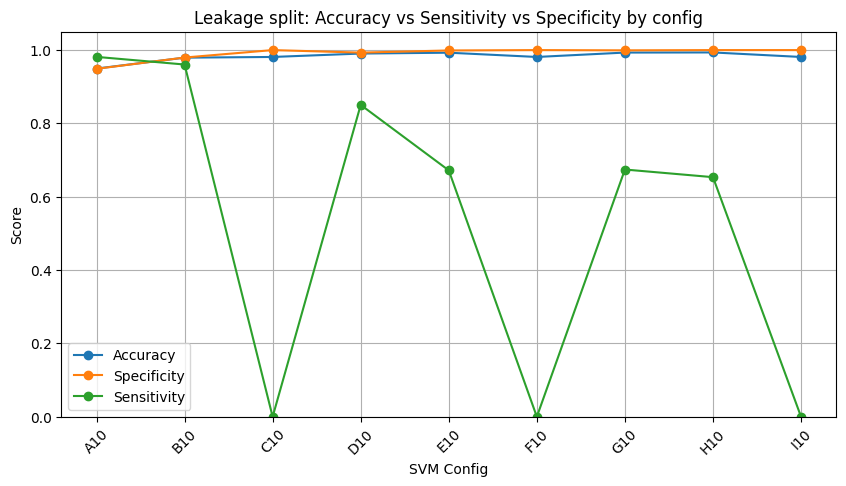

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("LEAKY_RESULTS_seizure_only.csv")


# Mean across patients for each config
config_summary = (
    df.groupby("config")
    [
        [
            "seg_accuracy",
            "seg_specificity",
            "seg_sensitivity"
        ]
    ]
    .mean()
    .reset_index()
)


print(config_summary)



# =====================================================
# Accuracy vs Sensitivity vs Specificity
# =====================================================

plt.figure(figsize=(10,5))


plt.plot(
    config_summary["config"],
    config_summary["seg_accuracy"],
    marker="o",
    label="Accuracy"
)


plt.plot(
    config_summary["config"],
    config_summary["seg_specificity"],
    marker="o",
    label="Specificity"
)


plt.plot(
    config_summary["config"],
    config_summary["seg_sensitivity"],
    marker="o",
    label="Sensitivity"
)


plt.xlabel("SVM Config")
plt.ylabel("Score")
plt.title(
    "Leakage split: Accuracy vs Sensitivity vs Specificity by config"
)

plt.xticks(rotation=45)

plt.ylim(0,1.05)

plt.grid(True)

plt.legend()

plt.show()

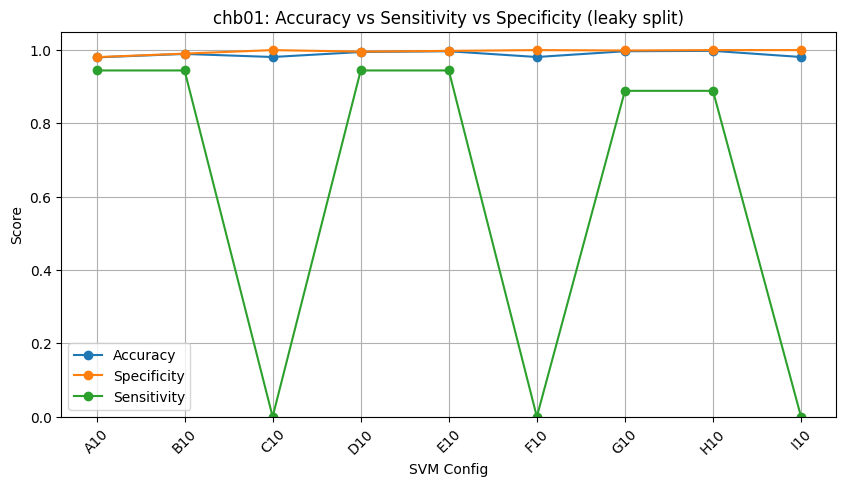

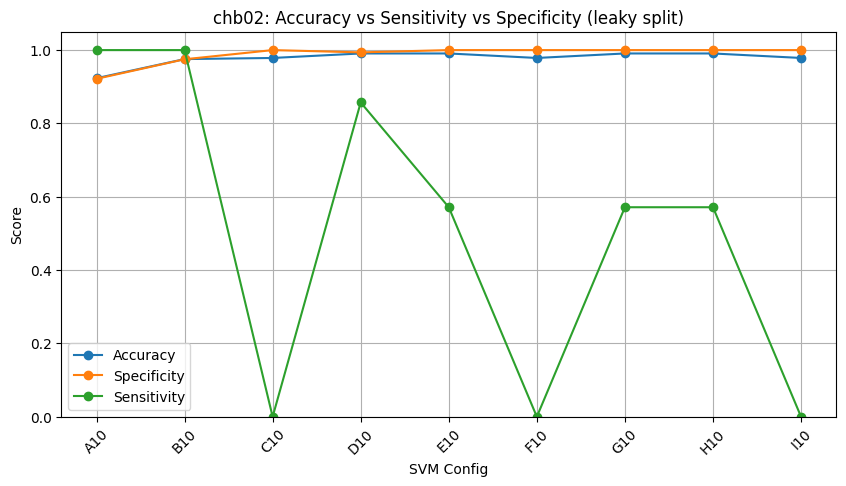

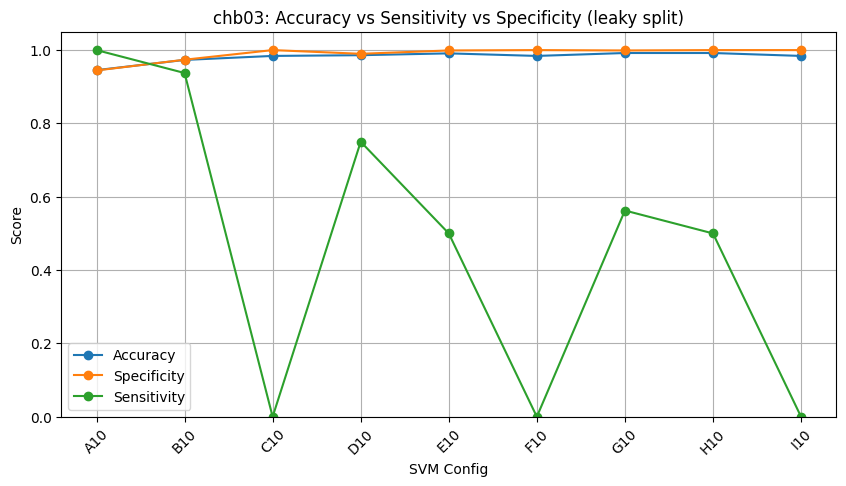

In [4]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("LEAKY_RESULTS_seizure_only.csv")


# =====================================================
# Plot each patient separately
# =====================================================

for patient in df["patient"].unique():

    d = df[df["patient"] == patient]


    plt.figure(figsize=(10,5))


    plt.plot(
        d["config"],
        d["seg_accuracy"],
        marker="o",
        label="Accuracy"
    )


    plt.plot(
        d["config"],
        d["seg_specificity"],
        marker="o",
        label="Specificity"
    )


    plt.plot(
        d["config"],
        d["seg_sensitivity"],
        marker="o",
        label="Sensitivity"
    )


    plt.xlabel("SVM Config")
    plt.ylabel("Score")

    plt.title(
        f"{patient}: Accuracy vs Sensitivity vs Specificity (leaky split)"
    )


    plt.xticks(rotation=45)

    plt.ylim(0,1.05)

    plt.grid(True)

    plt.legend()

    plt.show()

In [8]:
patient_config_summary = (
    df.groupby(["config", "patient"])
    [
        [
            "seg_accuracy",
            "seg_specificity",
            "seg_sensitivity",
            "roc_auc",
            "auprc",
            "seg_f1"
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(["config", "patient"])
)


patient_config_summary

,config,patient,seg_accuracy,seg_specificity,seg_sensitivity,roc_auc,auprc,seg_f1
0,A10,chb01,0.980105,0.980790,0.944444,0.996265,0.811876,0.641509
1,A10,chb02,0.923313,0.921630,1.000000,0.994178,0.889366,0.358974
2,A10,chb03,0.945328,0.944444,1.000000,0.985164,0.535446,0.367816
3,B10,chb01,0.989529,0.990395,0.944444,0.996383,0.794148,0.772727
4,B10,chb02,0.975460,0.974922,1.000000,0.995074,0.876190,0.636364
5,B10,chb03,0.973161,0.973737,0.937500,0.989520,0.581727,0.526316
6,C10,chb01,0.981152,1.000000,0.000000,0.998103,0.899994,0.000000
7,C10,chb02,0.978528,1.000000,0.000000,0.966861,0.377267,0.000000
8,C10,chb03,0.984095,1.000000,0.000000,0.974747,0.339722,0.000000
9,D10,chb01,0.994764,0.995731,0.944444,0.998873,0.938707,0.871795


In [9]:
import pandas as pd


df = pd.read_csv("LEAKY_RESULTS_seizure_only.csv")


ab = df[df["config"].isin(["A10", "B10"])]


table = (
    ab.groupby(["config", "patient"])
    [
        [
            "seg_accuracy",
            "seg_specificity",
            "seg_sensitivity",
            "roc_auc",
            "auprc",
            "seg_f1"
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(["config","patient"])
)


table

,config,patient,seg_accuracy,seg_specificity,seg_sensitivity,roc_auc,auprc,seg_f1
0,A10,chb01,0.980105,0.980790,0.944444,0.996265,0.811876,0.641509
1,A10,chb02,0.923313,0.921630,1.000000,0.994178,0.889366,0.358974
2,A10,chb03,0.945328,0.944444,1.000000,0.985164,0.535446,0.367816
3,B10,chb01,0.989529,0.990395,0.944444,0.996383,0.794148,0.772727
4,B10,chb02,0.975460,0.974922,1.000000,0.995074,0.876190,0.636364
5,B10,chb03,0.973161,0.973737,0.937500,0.989520,0.581727,0.526316


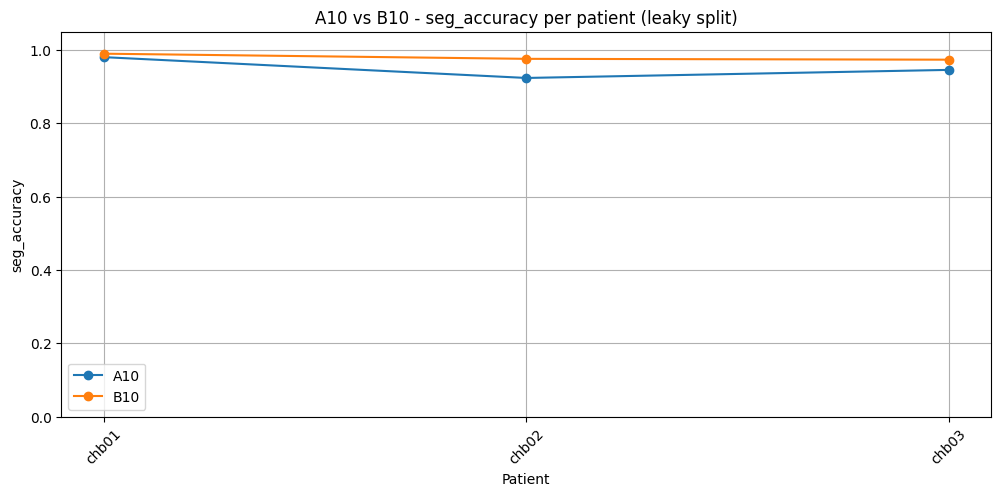

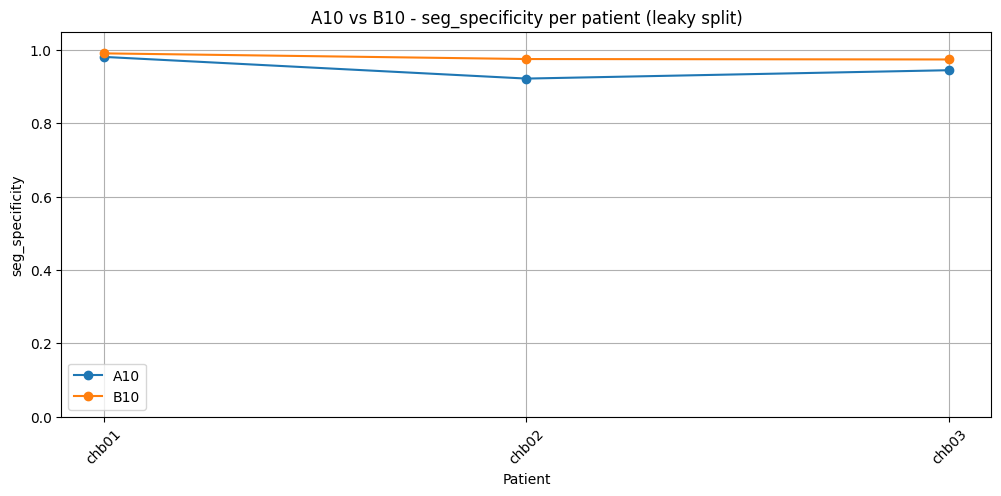

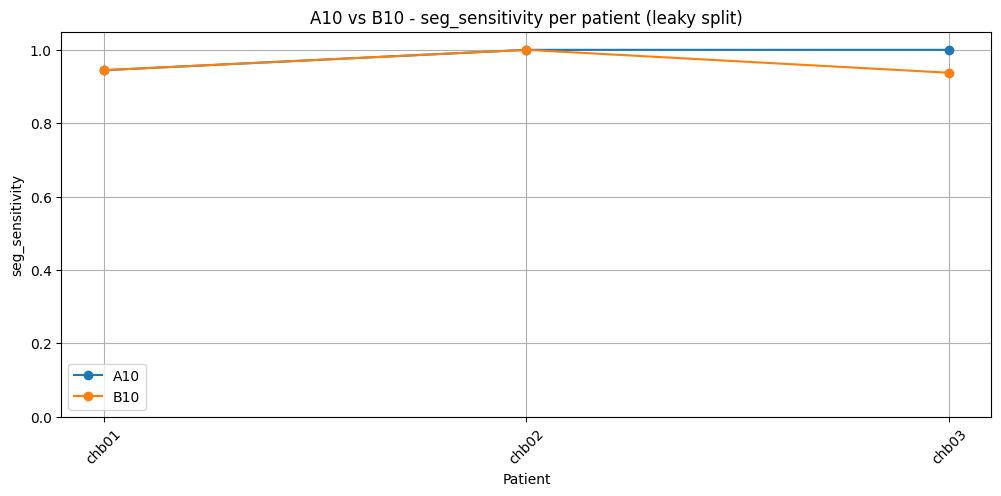

In [10]:
import matplotlib.pyplot as plt


metrics = [
    "seg_accuracy",
    "seg_specificity",
    "seg_sensitivity"
]


for metric in metrics:

    plt.figure(figsize=(12,5))


    for config in ["A10","B10"]:

        d = df[
            (df["config"] == config)
        ]

        plt.plot(
            d["patient"],
            d[metric],
            marker="o",
            label=config
        )


    plt.xlabel("Patient")
    plt.ylabel(metric)

    plt.title(
        f"A10 vs B10 - {metric} per patient (leaky split)"
    )

    plt.xticks(rotation=45)

    plt.ylim(0,1.05)

    plt.grid(True)

    plt.legend()

    plt.show()